# Multihazard Risk Screening of Rural Schools, Part 2: Model Selection

This notebook turns the expert rated survey into four deployed classifiers,
one per hazard, under a single reproducible protocol:

1. **Encoding.** Every attribute is ordinal encoded following the severity
   ordering declared in the schema, so the numeric representation preserves
   the specialist ranking. No scaling is applied: the candidates that benefit
   from it are distance or margin based, and the encoded integers already
   live on comparable small ranges.
2. **Split.** A stratified 80/20 train and holdout split with a fixed seed.
   The holdout is touched exactly once, at the end.
3. **Comparison.** Eleven candidate algorithms, from a frequency baseline to
   gradient boosted ensembles, are compared with ten fold stratified cross
   validation on the training partition across six metrics.
4. **Tuning.** The three strongest tree ensembles per hazard enter a
   randomized hyperparameter search, forty samples each, scored on macro F1.
   A tuned candidate is never allowed to replace its own default
   configuration unless it beats it under identical folds.
5. **Selection and audit.** The best tuned candidate is refit on the full
   training partition, evaluated on the holdout, and persisted together with
   a model card.

One deployment constraint is applied deliberately: although every family
takes part in the comparison, only tree ensembles are eligible for
deployment. The screening application attaches exact per prediction SHAP
attributions through the tree explainer, while other families would need
sampling based approximations. The eligible finalists sit within one cross
validation standard deviation of the overall best, so the constraint costs
essentially nothing and buys exact interpretability.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "schoolrisk").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import pandas as pd

from schoolrisk.config import HAZARDS, RISK_LEVELS
from schoolrisk.data import load_dataset, split_dataset
from schoolrisk.modeling import (
    DEPLOYABLE_MODELS,
    MODEL_DISPLAY,
    PRIMARY_METRIC,
    compare_models,
    evaluate_holdout,
    save_model,
    tune_model,
)
from schoolrisk.plots import apply_style, confusion_grid_figure, cv_comparison_figure

apply_style()

## 1. Partitions

In [3]:
splits = {}
rows = []
for hazard, schema in HAZARDS.items():
    df = load_dataset(hazard)
    X_train, X_test, y_train, y_test = split_dataset(df)
    splits[hazard] = (X_train, X_test, y_train, y_test)
    rows.append(
        {
            "Hazard": schema.display,
            "Records": len(df),
            "Training": len(X_train),
            "Holdout": len(X_test),
            "Holdout share": f"{len(X_test) / len(df):.0%}",
        }
    )
pd.DataFrame(rows)

,Hazard,Records,Training,Holdout,Holdout share
0,Earthquake,266,212,54,20%
1,Landslide,150,120,30,20%
2,Flood,216,172,44,20%
3,Windstorm,137,109,28,20%


## 2. The candidates

The zoo spans distinct inductive biases on purpose: linear decision surfaces,
distance based neighbors, a generative baseline, single trees, bagged and
boosted ensembles, and a kernel machine. The most frequent class predictor
anchors the bottom of the table; any candidate must clear it by a wide margin
to matter.

In [4]:
pd.DataFrame(
    {"Key": list(MODEL_DISPLAY), "Model": list(MODEL_DISPLAY.values())}
)

,Key,Model
0,baseline,Most frequent baseline
1,logreg,Logistic regression
2,knn,K nearest neighbors
3,nbayes,Gaussian naive Bayes
4,dtree,Decision tree
5,rf,Random forest
6,et,Extra trees
7,gboost,Gradient boosting
8,ada,AdaBoost
9,svm,Support vector machine


## 3. Cross validated comparison

Mean and standard deviation over ten stratified folds of the training
partition. Tables are sorted by macro F1, the primary metric of the study.

In [5]:
comparisons = {}
for hazard in HAZARDS:
    X_train, _, y_train, _ = splits[hazard]
    comparisons[hazard] = compare_models(hazard, X_train, y_train)

for hazard, table in comparisons.items():
    print(f"{HAZARDS[hazard].display}")
    display(
        table.drop(columns="key").round(4).head(6).style.hide(axis="index")
    )

Earthquake


model,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std,f1_macro,f1_macro_std,mcc,mcc_std,kappa,kappa_std,roc_auc,roc_auc_std
Support vector machine,0.962300,0.035000,0.960700,0.038600,0.960300,0.038200,0.945300,0.051200,0.943100,0.053000,0.996600,0.004800
Random forest,0.957400,0.058100,0.956200,0.058300,0.956900,0.057200,0.938700,0.084200,0.935800,0.087200,0.995300,0.009300
Extra trees,0.952600,0.063900,0.951400,0.064000,0.951700,0.063900,0.932900,0.090600,0.928700,0.095800,0.994800,0.009100
AdaBoost,0.943300,0.035800,0.945800,0.034200,0.942800,0.035600,0.920400,0.049400,0.915100,0.053500,0.986900,0.009300
LightGBM,0.943300,0.059200,0.941700,0.060900,0.941400,0.061100,0.917400,0.086200,0.914500,0.089100,0.993900,0.010200
Gradient boosting,0.938500,0.052100,0.936900,0.052700,0.937500,0.052600,0.909100,0.077600,0.907600,0.078200,0.991500,0.011600


Landslide


model,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std,f1_macro,f1_macro_std,mcc,mcc_std,kappa,kappa_std,roc_auc,roc_auc_std
Logistic regression,0.925000,0.069200,0.922200,0.073300,0.921200,0.074200,0.895500,0.097000,0.887000,0.104500,0.993600,0.013600
LightGBM,0.925000,0.078600,0.922200,0.082200,0.920600,0.084600,0.893500,0.112200,0.887000,0.118600,0.990200,0.015900
Extra trees,0.925000,0.087000,0.922200,0.092800,0.919300,0.096400,0.892100,0.127400,0.887100,0.131300,0.989200,0.014900
Random forest,0.925000,0.069200,0.922200,0.073300,0.918900,0.077100,0.895500,0.097000,0.887000,0.104500,0.988000,0.023200
Support vector machine,0.908300,0.069200,0.905600,0.072600,0.904000,0.073800,0.868100,0.101600,0.862000,0.104400,0.980700,0.026500
Gradient boosting,0.908300,0.078600,0.905600,0.081600,0.903800,0.083800,0.869200,0.112700,0.862000,0.118400,0.981500,0.029400


Flood


model,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std,f1_macro,f1_macro_std,mcc,mcc_std,kappa,kappa_std,roc_auc,roc_auc_std
LightGBM,0.942200,0.072900,0.949200,0.063500,0.946900,0.067400,0.916900,0.104700,0.911200,0.111700,0.993000,0.016600
Logistic regression,0.941500,0.069600,0.944000,0.064400,0.944800,0.064500,0.914600,0.101100,0.909400,0.108000,0.989200,0.026700
Random forest,0.918000,0.070700,0.928600,0.063700,0.925600,0.067000,0.880000,0.102300,0.873100,0.108800,0.993300,0.010500
Gradient boosting,0.918600,0.064100,0.929400,0.059000,0.924400,0.062200,0.884400,0.089200,0.874300,0.098900,0.993000,0.019500
Extra trees,0.918300,0.065200,0.925000,0.061700,0.924400,0.061900,0.882000,0.093500,0.873300,0.100800,0.994600,0.007400
Support vector machine,0.912100,0.084300,0.909500,0.091100,0.909000,0.087600,0.871900,0.124800,0.862500,0.132600,0.987900,0.017000


Windstorm


model,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std,f1_macro,f1_macro_std,mcc,mcc_std,kappa,kappa_std,roc_auc,roc_auc_std
Extra trees,0.898200,0.077700,0.918300,0.064700,0.913000,0.068100,0.844400,0.123100,0.835800,0.127300,0.967100,0.051100
Random forest,0.889100,0.107400,0.911700,0.086600,0.902200,0.094100,0.831000,0.166500,0.822900,0.170800,0.970900,0.037800
Logistic regression,0.879100,0.112100,0.905000,0.086000,0.897400,0.097200,0.821200,0.164200,0.805700,0.179100,0.982800,0.024800
Support vector machine,0.861800,0.085000,0.885000,0.071700,0.885400,0.072000,0.782000,0.136400,0.774600,0.137900,0.955900,0.064600
LightGBM,0.870900,0.110100,0.888300,0.088500,0.878600,0.102300,0.806300,0.165200,0.795000,0.170900,0.980100,0.020000
Gaussian naive Bayes,0.843600,0.135600,0.880000,0.108500,0.866500,0.126200,0.772000,0.200600,0.756300,0.206200,0.945800,0.058800


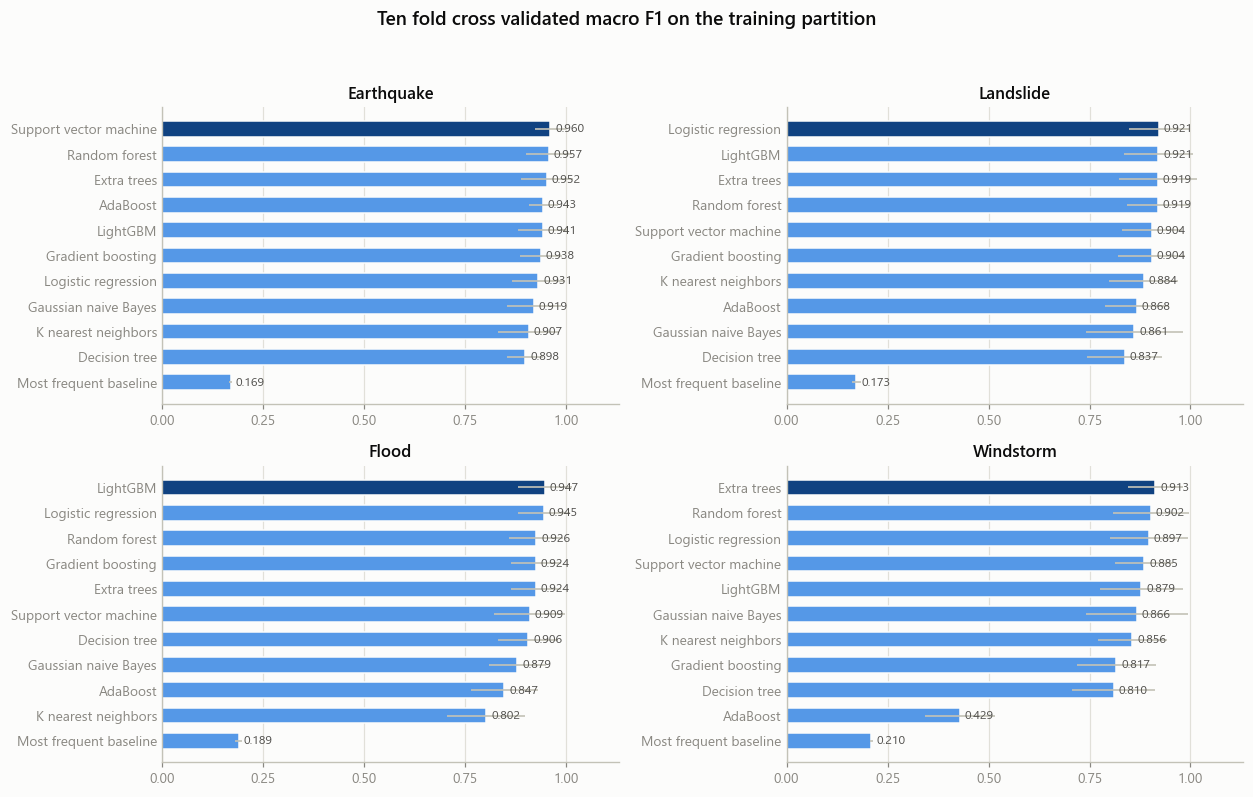

In [6]:
fig = cv_comparison_figure(comparisons)

Two readings stand out. Tree ensembles sit at or near the top for every
hazard, the expected outcome for small tabular problems with ordinal
categorical structure. And the regularized linear model is remarkably
competitive, which says something real about the data: the severity ordered
encoding makes the expert criteria close to linearly separable. The margins
among the leaders are within one cross validation standard deviation, so the
tuning stage, not this table, gets the final word.

## 4. Randomized tuning of the finalists

The three strongest deployment eligible ensembles per hazard are tuned with
forty randomized configurations each under the same ten folds.

In [7]:
finalists = {
    hazard: [k for k in table["key"] if k in DEPLOYABLE_MODELS][:3]
    for hazard, table in comparisons.items()
}
tuned = {}
for hazard, keys in finalists.items():
    X_train, _, y_train, _ = splits[hazard]
    tuned[hazard] = [tune_model(hazard, key, X_train, y_train) for key in keys]

rows = []
for hazard, candidates in tuned.items():
    for candidate in sorted(candidates, key=lambda c: -c.cv_score):
        rows.append(
            {
                "Hazard": HAZARDS[hazard].display,
                "Candidate": candidate.display,
                f"Tuned CV {PRIMARY_METRIC}": round(candidate.cv_score, 4),
            }
        )
pd.DataFrame(rows)

,Hazard,Candidate,Tuned CV f1_macro
0,Earthquake,LightGBM,0.9665
1,Earthquake,Random forest,0.9616
2,Earthquake,Extra trees,0.9611
3,Landslide,LightGBM,0.9381
4,Landslide,Extra trees,0.9360
5,Landslide,Random forest,0.9289
6,Flood,LightGBM,0.9626
7,Flood,Random forest,0.9423
8,Flood,Extra trees,0.9406
9,Windstorm,Extra trees,0.9157


## 5. Holdout audit of the selected models

The winner per hazard sees the holdout exactly once. Alongside accuracy, the
table reports balanced accuracy, macro F1, Matthews correlation and macro one
versus rest ROC AUC, which stay informative under the windstorm class
imbalance.

In [8]:
winners = {}
holdouts = {}
rows = []
for hazard, candidates in tuned.items():
    winner = max(candidates, key=lambda c: c.cv_score)
    winners[hazard] = winner
    X_train, X_test, y_train, y_test = splits[hazard]
    holdouts[hazard] = evaluate_holdout(winner.pipeline, X_test, y_test)
    rows.append(
        {
            "Hazard": HAZARDS[hazard].display,
            "Selected model": winner.display,
            **{k: round(v, 4) for k, v in holdouts[hazard]["metrics"].items()},
        }
    )
summary = pd.DataFrame(rows)
summary

,Hazard,Selected model,accuracy,balanced_accuracy,f1_macro,f1_weighted,mcc,kappa,roc_auc
0,Earthquake,LightGBM,0.9630,0.9649,0.9619,0.9630,0.9464,0.9444,0.9989
1,Landslide,LightGBM,0.8333,0.8333,0.8329,0.8329,0.7513,0.7500,0.9533
2,Flood,LightGBM,0.9773,0.9804,0.9804,0.9773,0.9658,0.9650,1.0000
3,Windstorm,Extra trees,0.8929,0.9154,0.9124,0.8933,0.8313,0.8296,0.9893


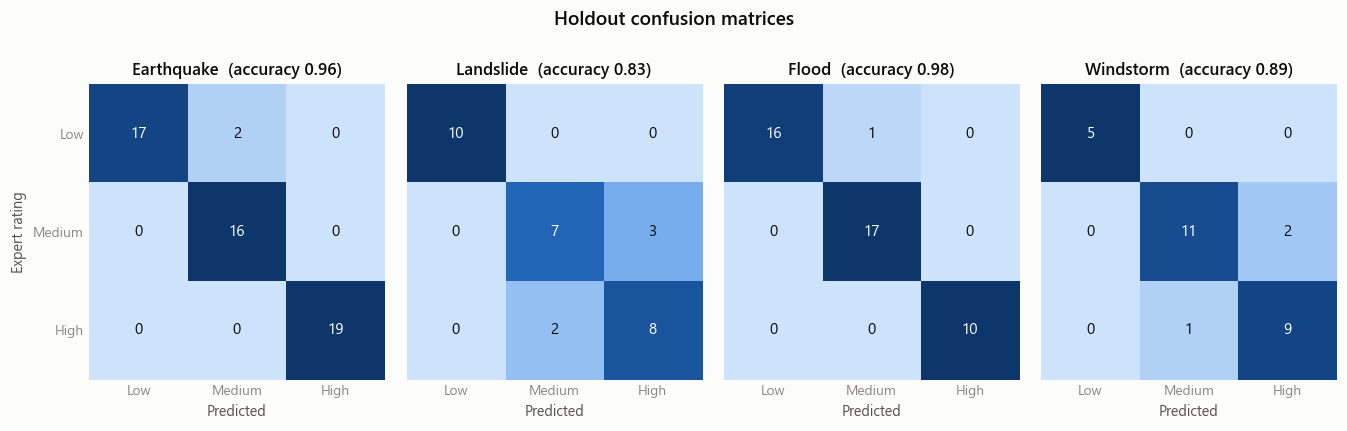

In [9]:
fig = confusion_grid_figure(holdouts)

Misclassifications, when they occur, land in the adjacent class: a Medium
building read as High or the reverse. Confusions between the extreme classes
would be the costly error for a screening tool and none appear.

In [10]:
for hazard in HAZARDS:
    print(HAZARDS[hazard].display)
    display(holdouts[hazard]["report"].round(3))

Earthquake


,precision,recall,f1-score,support
Low,1.000,0.895,0.944,19.000
Medium,0.889,1.000,0.941,16.000
High,1.000,1.000,1.000,19.000
accuracy,0.963,0.963,0.963,0.963
macro avg,0.963,0.965,0.962,54.000
weighted avg,0.967,0.963,0.963,54.000


Landslide


,precision,recall,f1-score,support
Low,1.000,1.000,1.000,10.000
Medium,0.778,0.700,0.737,10.000
High,0.727,0.800,0.762,10.000
accuracy,0.833,0.833,0.833,0.833
macro avg,0.835,0.833,0.833,30.000
weighted avg,0.835,0.833,0.833,30.000


Flood


,precision,recall,f1-score,support
Low,1.000,0.941,0.970,17.000
Medium,0.944,1.000,0.971,17.000
High,1.000,1.000,1.000,10.000
accuracy,0.977,0.977,0.977,0.977
macro avg,0.981,0.980,0.980,44.000
weighted avg,0.979,0.977,0.977,44.000


Windstorm


,precision,recall,f1-score,support
Low,1.000,1.000,1.000,5.000
Medium,0.917,0.846,0.880,13.000
High,0.818,0.900,0.857,10.000
accuracy,0.893,0.893,0.893,0.893
macro avg,0.912,0.915,0.912,28.000
weighted avg,0.896,0.893,0.893,28.000


## 6. Persistence

Each fitted pipeline, encoder plus model, is serialized next to a model card
holding the schema, the chosen hyperparameters, the metrics and the
environment versions. The application and the following notebooks consume
these artifacts.

In [11]:
for hazard, winner in winners.items():
    X_train, X_test, y_train, y_test = splits[hazard]
    path = save_model(hazard, winner, holdouts[hazard], len(X_train), len(X_test))
    print(f"{HAZARDS[hazard].display:10s} {winner.display:22s} -> {path.name}")

Earthquake LightGBM               -> earthquake_model.pkl
Landslide  LightGBM               -> landslide_model.pkl
Flood      LightGBM               -> flood_model.pkl


Windstorm  Extra trees            -> windstorm_model.pkl


## Reading the result

* Cross validated macro F1 lands between 0.92 and 0.97 for every hazard, and
  the holdout audits confirm it, from 0.83 on the thirty record landslide
  holdout to 0.98 on flood.
* Every single holdout error is an adjacent class confusion, a Medium read
  as High or the reverse. No Low building is ever called High and no High
  building is ever called Low, which is the failure mode that would matter
  for a screening tool.
* The exercise validates the premise of the study: the specialist rating
  behaves like a learnable function of the survey attributes, so the expert
  criteria are internally consistent.
* With a few hundred records, cross validation dispersion is the honest
  uncertainty measure; the next notebook checks that the models also agree
  with engineering intuition on **why** buildings are risky, which is a
  stronger safeguard against learning artifacts.